In [11]:
import astropy.constants as const
import astropy.units as u
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

from plotting import label_axes

In [12]:
from typing import cast
from astropy.cosmology import WMAP9 as cosmo
from astropy.cosmology import Cosmology

cosmo = cast(Cosmology, cosmo)


def one_over_H_Myr(z: float) -> float:
    return (
        (1 / (cosmo.H0 * (1 + z) * np.sqrt((1 + z) ** 3 * cosmo.Om0 + cosmo.Ode0)))
        .to(u.Myr)
        .value
    )

In [13]:
from scipy import integrate

def t(z: float) -> float:
    res, tol = integrate.quad(one_over_H_Myr, z, np.inf)
    return res * u.Myr

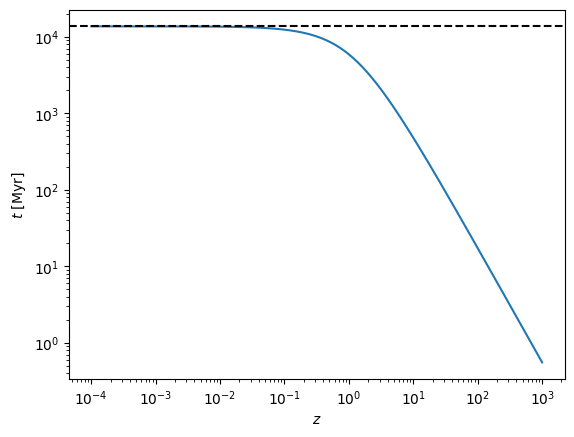

In [14]:
fig, ax = plt.subplots()

z_grid = np.logspace(-4, 3, 300)
ax.loglog(z_grid, u.Quantity([t(z) for z in z_grid]))
ax.axhline(13.787 * u.Gyr, color="k", linestyle="--")
label_axes(ax, "z", "t")
plt.show()

## Light travel distance

In [15]:
def D_T(z: float) -> u.Quantity[u.Mpc]:
    res, tol = integrate.quad(one_over_H_Myr, 0, z)
    return ((res * u.Myr) * const.c).to(u.Mpc)

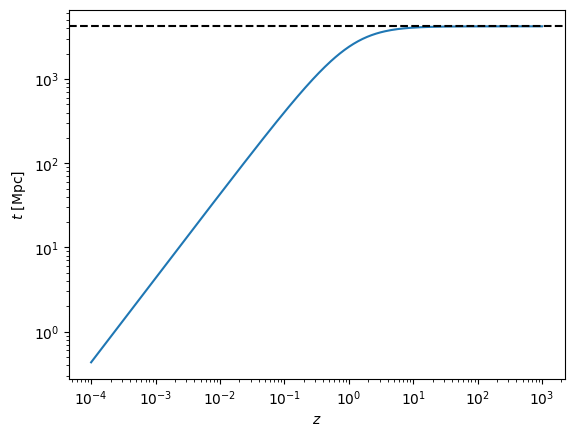

In [16]:
fig, ax = plt.subplots()

ax.loglog(z_grid, u.Quantity([D_T(z) for z in z_grid]))
ax.axhline(const.c * 13.787 * u.Gyr, color="k", linestyle="--")
label_axes(ax, "z", "t")
plt.show()